# Counting Items in Amazon Warehouse Bins (UE24CS352A ML Mini-Project)

**Task:** given a photo of a warehouse bin, predict how many items (0-5) it holds.

**Data:** Amazon Bin Image Dataset (AWS Open Data, public S3 bucket `aft-vbi-pds`).

**Reference:** Bertorello et al., "Amazon Inventory Reconciliation Using AI", Stanford CS229, 2018.

## 1. Setup

In [1]:
import os, io, json, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "NO GPU - switch runtime to T4")

device: cuda | Tesla T4


In [2]:
#CONFIG
ID_START, ID_END = 1, 60000
MAX_ITEMS = 5                 #Just like it is in the paper, we are keeping bins 0..5 size.
NUM_CLASSES = MAX_ITEMS + 1
IMG = 160
BATCH = 64
EPOCHS = 15
WORKERS = 32                  #no. of download threads
CACHE = "/content/bins_cache_v2.npz"

## 2. Data: download, resize and cache
Each image has a metadata JSON with `EXPECTED_QUANTITY` (our label). We decided to keep only bins with 0-5 items
and resize every photo to `IMG x IMG`.
Cache is saved so a restart does not re-download.

In [3]:
import requests
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

BASE = "https://aft-vbi-pds.s3.amazonaws.com"
session = requests.Session()
session.mount("https://", requests.adapters.HTTPAdapter(pool_connections=64, pool_maxsize=64, max_retries=3))

def fetch(i):
    try:
        m = session.get(f"{BASE}/metadata/{i}.json", timeout=20)
        if m.status_code != 200:
            return None
        q = m.json()["EXPECTED_QUANTITY"]
        if q > MAX_ITEMS:
            return None
        r = session.get(f"{BASE}/bin-images/{i}.jpg", timeout=30)
        if r.status_code != 200:
            return None
        img = Image.open(io.BytesIO(r.content)).convert("RGB").resize((IMG, IMG), Image.BILINEAR)
        return i, q, np.asarray(img, dtype=np.uint8)
    except Exception:
        return None

if os.path.exists(CACHE):
    d = np.load(CACHE)
    ids, y_all, X_all = d["ids"], d["y"], d["X"]
    print("loaded cache:", X_all.shape)
else:
    t0 = time.time()
    with ThreadPoolExecutor(WORKERS) as ex:
        res = list(tqdm(ex.map(fetch, range(ID_START, ID_END + 1)), total=ID_END - ID_START + 1))
    res = [r for r in res if r]
    ids = np.array([r[0] for r in res]); y_all = np.array([r[1] for r in res]); X_all = np.stack([r[2] for r in res])
    np.savez(CACHE, ids=ids, y=y_all, X=X_all)
    print(f"downloaded {len(res)} usable images in {time.time()-t0:.0f}s ->", X_all.shape)

loaded cache: (48206, 160, 160, 3)


In [4]:
from sklearn.model_selection import train_test_split

#70 / 20 / 10 stratified split, same split every run
idx = np.arange(len(y_all))
tr_idx, te_idx = train_test_split(idx, test_size=0.10, stratify=y_all, random_state=SEED)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.20/0.90, stratify=y_all[tr_idx], random_state=SEED)
print("train/val/test:", len(tr_idx), len(va_idx), len(te_idx))

Xtr, ytr = X_all[tr_idx], y_all[tr_idx]
Xva, yva = X_all[va_idx], y_all[va_idx]
Xte, yte = X_all[te_idx], y_all[te_idx]

train/val/test: 33743 9642 4821


## 3. Exploratory analysis

class counts: {0: np.int64(1454), 1: np.int64(5483), 2: np.int64(10205), 3: np.int64(11948), 4: np.int64(10672), 5: np.int64(8444)}
random-guess baseline accuracy: 16.7%   majority-class baseline: 24.8%


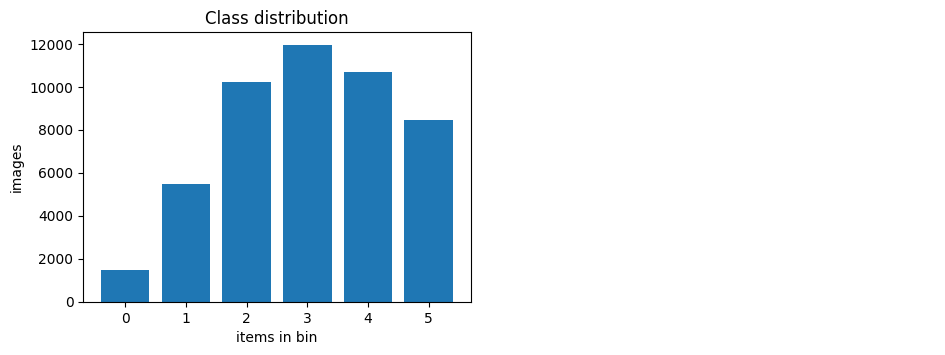

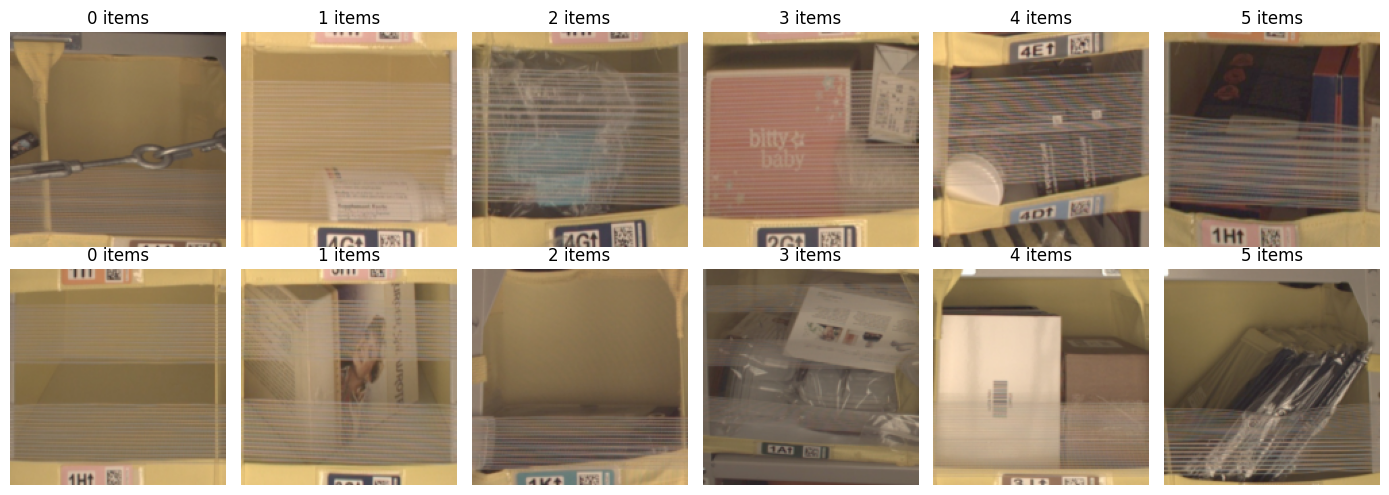

In [5]:
counts = np.bincount(y_all, minlength=NUM_CLASSES)
print("class counts:", dict(enumerate(counts)))
print("random-guess baseline accuracy: %.1f%%   majority-class baseline: %.1f%%" % (100/NUM_CLASSES, 100*counts.max()/counts.sum()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(range(NUM_CLASSES), counts); ax[0].set_xlabel("items in bin"); ax[0].set_ylabel("images"); ax[0].set_title("Class distribution")
ax[1].axis("off")
fig2, axs = plt.subplots(2, 6, figsize=(14, 5))
for c in range(NUM_CLASSES):
    ii = np.where(y_all == c)[0][:2]
    for r, j in enumerate(ii):
        axs[r, c].imshow(X_all[j]); axs[r, c].set_title(f"{c} items"); axs[r, c].axis("off")
plt.tight_layout(); plt.show()

## 4. Classical baselines (raw pixels -> PCA -> classifier)
Images are average-pooled to 32x32x3 (3072 features), standardised, reduced with PCA, then fed to logistic regression and an RBF SVM.
Trained on a subsample (`N_BASE`) because SVMs scale poorly. Hyperparameter `C` is chosen on the validation set.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

N_BASE = 8000
def small(X, s=32):
    k = X.shape[1] // s
    return X.reshape(len(X), s, k, s, k, 3).mean((2, 4)).reshape(len(X), -1).astype(np.float32)

rng = np.random.RandomState(SEED)
sub = rng.choice(len(Xtr), min(N_BASE, len(Xtr)), replace=False)
Btr, Bva, Bte = small(Xtr[sub]), small(Xva), small(Xte)
ysub = ytr[sub]

scaler = StandardScaler().fit(Btr)
pca = PCA(n_components=100, svd_solver="randomized", random_state=SEED).fit(scaler.transform(Btr))
Ptr, Pva, Pte = [pca.transform(scaler.transform(a)) for a in (Btr, Bva, Bte)]
print("PCA explained variance: %.1f%%" % (100 * pca.explained_variance_ratio_.sum()))

results = {}   # model name -> dict(test_acc, test_rmse)
def rmse(y, p): return float(np.sqrt(np.mean((y - p) ** 2)))

lr_clf = LogisticRegression(max_iter=1000).fit(Ptr, ysub)
p = lr_clf.predict(Pte)
results["Logistic Regression (PCA)"] = dict(val_acc=accuracy_score(yva, lr_clf.predict(Pva)), test_acc=accuracy_score(yte, p), test_rmse=rmse(yte, p))

best = None
for C in [1, 10, 100]:
    s = SVC(C=C, kernel="rbf", gamma="scale").fit(Ptr, ysub)
    va = accuracy_score(yva, s.predict(Pva)); print(f"SVM C={C}: val acc {va:.3f}")
    if best is None or va > best[0]:
        best = (va, C, s)
va, C, svm = best
p = svm.predict(Pte)
results[f"SVM RBF (PCA, C={C})"] = dict(val_acc=va, test_acc=accuracy_score(yte, p), test_rmse=rmse(yte, p))
svm_pred = p
print(pd.DataFrame(results).T.round(3))

PCA explained variance: 90.7%
SVM C=1: val acc 0.294
SVM C=10: val acc 0.274
SVM C=100: val acc 0.267
                           val_acc  test_acc  test_rmse
Logistic Regression (PCA)    0.288     0.272      1.433
SVM RBF (PCA, C=1)           0.294     0.295      1.340


## 5. CNN with transfer learning (ResNet pretrained on ImageNet)
We replace the final layer with a 6-way classifier and train with cross-entropy, Adam, cosine learning-rate decay, mixed precision and horizontal-flip augmentation.
Two experiments are compared:
- **A. Frozen backbone** (train only the new final layer = feature extraction)
- **B. Full fine-tuning** (train all layers)

In [7]:
Xtr_t, Xva_t, Xte_t = [torch.from_numpy(a) for a in (Xtr, Xva, Xte)]
ytr_t, yva_t, yte_t = [torch.from_numpy(a).long() for a in (ytr, yva, yte)]
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def batches(X, y, bs, shuffle=False, augment=False):
    order = torch.randperm(len(X)) if shuffle else torch.arange(len(X))
    for s in range(0, len(X), bs):
        b = order[s:s + bs]
        xb = X[b].to(device, non_blocking=True).permute(0, 3, 1, 2).float().div_(255)
        if augment:
            flip = torch.rand(len(b), device=device) < 0.5
            xb = torch.where(flip.view(-1, 1, 1, 1), xb.flip(3), xb)
            pad = 8                                           # random shift
            xb = F.pad(xb, (pad,) * 4, mode="reflect")
            dx, dy = random.randint(0, 2 * pad), random.randint(0, 2 * pad)
            xb = xb[:, :, dy:dy + IMG, dx:dx + IMG]
            xb = (xb * (0.8 + 0.4 * torch.rand(len(b), 1, 1, 1, device=device))).clamp_(0, 1)  # brightness
        yield (xb - mean) / std, y[b].to(device)

def build(arch="resnet18", freeze=False):
    w = {"resnet18": models.ResNet18_Weights.DEFAULT, "resnet34": models.ResNet34_Weights.DEFAULT}[arch]
    m = getattr(models, arch)(weights=w)
    if freeze:
        for p_ in m.parameters():
            p_.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(device)

@torch.no_grad()
def predict_all(model, X, y, bs=256):
    model.eval(); preds = []; probs = []
    for xb, _ in batches(X, y, bs):
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            o = (model(xb) + model(xb.flip(3))) / 2
        probs.append(F.softmax(o.float(), 1).cpu()); preds.append(o.argmax(1).cpu())
    return torch.cat(preds).numpy(), torch.cat(probs).numpy()

def train_model(arch="resnet18", freeze=False, lr=3e-4, epochs=EPOCHS, tag=""):
    model = build(arch, freeze)
    params = [p_ for p_ in model.parameters() if p_.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler_amp = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    hist = dict(train_loss=[], train_acc=[], val_acc=[]); best_va, best_state = -1, None
    for ep in range(epochs):
        model.train(); t0 = time.time(); tl = tc = n = 0
        for xb, yb in batches(Xtr_t, ytr_t, BATCH, shuffle=True, augment=True):
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                out = model(xb); loss = crit(out, yb)
            scaler_amp.scale(loss).backward(); scaler_amp.step(opt); scaler_amp.update()
            tl += loss.item() * len(yb); tc += (out.argmax(1) == yb).sum().item(); n += len(yb)
        sched.step()
        pv, _ = predict_all(model, Xva_t, yva_t); va = float((pv == yva).mean())
        hist["train_loss"].append(tl / n); hist["train_acc"].append(tc / n); hist["val_acc"].append(va)
        if va > best_va:
            best_va = va; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"[{tag or arch}] epoch {ep+1:02d}/{epochs}  loss {tl/n:.3f}  train acc {tc/n:.3f}  val acc {va:.3f}  ({time.time()-t0:.0f}s)")
    model.load_state_dict(best_state)
    return model, hist

In [8]:
# Experiment A: frozen backbone (only the new final layer is trained)
model_A, hist_A = train_model("resnet18", freeze=True, lr=1e-3, epochs=6, tag="A frozen")

[A frozen] epoch 01/6  loss 1.634  train acc 0.276  val acc 0.307  (19s)
[A frozen] epoch 02/6  loss 1.578  train acc 0.307  val acc 0.314  (17s)
[A frozen] epoch 03/6  loss 1.569  train acc 0.317  val acc 0.324  (16s)
[A frozen] epoch 04/6  loss 1.552  train acc 0.326  val acc 0.320  (16s)
[A frozen] epoch 05/6  loss 1.547  train acc 0.330  val acc 0.328  (16s)
[A frozen] epoch 06/6  loss 1.541  train acc 0.339  val acc 0.329  (16s)


In [9]:
# Experiment B: full fine-tuning of ResNet18
model_B, hist_B = train_model("resnet18", freeze=False, lr=3e-4, epochs=EPOCHS, tag="B finetune")

[B finetune] epoch 01/15  loss 1.469  train acc 0.371  val acc 0.407  (38s)
[B finetune] epoch 02/15  loss 1.364  train acc 0.439  val acc 0.443  (37s)
[B finetune] epoch 03/15  loss 1.330  train acc 0.464  val acc 0.466  (37s)
[B finetune] epoch 04/15  loss 1.300  train acc 0.483  val acc 0.462  (37s)
[B finetune] epoch 05/15  loss 1.272  train acc 0.500  val acc 0.486  (37s)
[B finetune] epoch 06/15  loss 1.240  train acc 0.524  val acc 0.493  (38s)
[B finetune] epoch 07/15  loss 1.207  train acc 0.549  val acc 0.504  (38s)
[B finetune] epoch 08/15  loss 1.167  train acc 0.575  val acc 0.484  (37s)
[B finetune] epoch 09/15  loss 1.113  train acc 0.614  val acc 0.489  (37s)
[B finetune] epoch 10/15  loss 1.053  train acc 0.654  val acc 0.491  (37s)
[B finetune] epoch 11/15  loss 0.984  train acc 0.701  val acc 0.499  (37s)
[B finetune] epoch 12/15  loss 0.906  train acc 0.751  val acc 0.484  (37s)
[B finetune] epoch 13/15  loss 0.842  train acc 0.788  val acc 0.484  (37s)
[B finetune]

Optional experiment C (deeper network). Takes longer; run only if time allows.

In [10]:
RUN_C = True
if RUN_C:
    model_C, hist_C = train_model("resnet34", freeze=False, lr=3e-4, epochs=EPOCHS, tag="C resnet34")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 79.0MB/s]


KeyboardInterrupt: 

## 6. Evaluation on the held-out test set

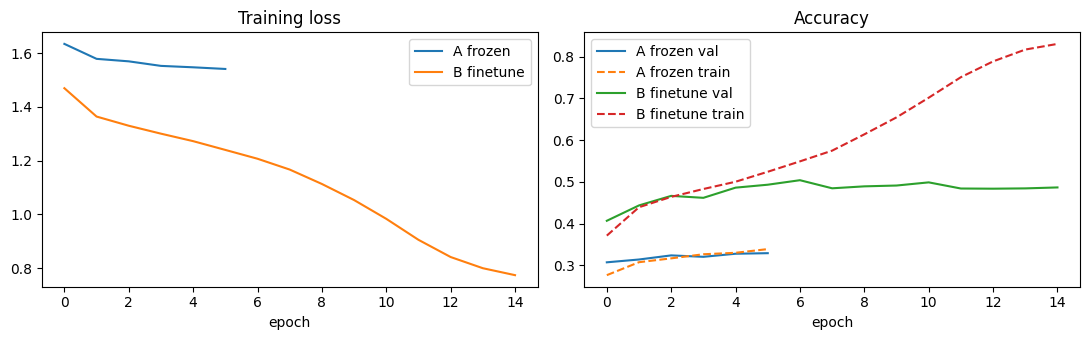

,val_acc,test_acc,test_rmse
Logistic Regression (PCA),0.288,0.272,1.433
"SVM RBF (PCA, C=1)",0.294,0.295,1.340
A frozen ResNet18,0.329,0.324,1.318
B fine-tuned ResNet18,0.504,0.486,1.012
Paper: SVM (PCA),NaN,0.320,NaN
Paper: ResNet34 Adam (324K imgs),0.562,NaN,0.900


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for name, h in [("A frozen", hist_A), ("B finetune", hist_B)]:
    ax[0].plot(h["train_loss"], label=name)
    ax[1].plot(h["val_acc"], label=name + " val"); ax[1].plot(h["train_acc"], "--", label=name + " train")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); plt.tight_layout(); plt.show()

final = {"A frozen ResNet18": model_A, "B fine-tuned ResNet18": model_B}
if "model_C" in globals():
    final["C fine-tuned ResNet34"] = model_C
preds = {}
for name, m in final.items():
    p, pr = predict_all(m, Xte_t, yte_t)
    preds[name] = (p, pr)
    pv, _ = predict_all(m, Xva_t, yva_t)
    results[name] = dict(val_acc=float((pv == yva).mean()), test_acc=float((p == yte).mean()), test_rmse=rmse(yte, p))

paper = pd.DataFrame({"Paper: SVM (PCA)": dict(val_acc=np.nan, test_acc=0.32, test_rmse=np.nan),
                      "Paper: ResNet34 Adam (324K imgs)": dict(val_acc=0.562, test_acc=np.nan, test_rmse=0.90)}).T
table = pd.concat([pd.DataFrame(results).T, paper]).round(3)
table

Best model (by val acc): B fine-tuned ResNet18
              precision    recall  f1-score   support

           0      0.972     0.966     0.969       145
           1      0.667     0.821     0.736       548
           2      0.473     0.603     0.531      1021
           3      0.397     0.411     0.404      1195
           4      0.399     0.338     0.366      1067
           5      0.508     0.337     0.405       845

    accuracy                          0.486      4821
   macro avg      0.569     0.579     0.568      4821
weighted avg      0.481     0.486     0.477      4821



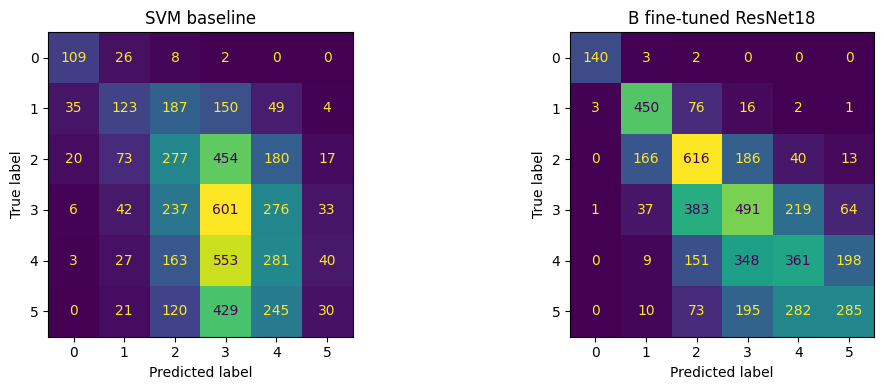

per-class accuracy: {0: 0.966, 1: 0.821, 2: 0.603, 3: 0.411, 4: 0.338, 5: 0.337}


In [12]:
best_name = max(final, key=lambda k: results[k]["val_acc"])   # pick by validation accuracy, report on test
p, pr = preds[best_name]
print("Best model (by val acc):", best_name)
print(classification_report(yte, p, digits=3))

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(yte, svm_pred, labels=range(NUM_CLASSES))).plot(ax=ax[0], colorbar=False); ax[0].set_title("SVM baseline")
ConfusionMatrixDisplay(confusion_matrix(yte, p, labels=range(NUM_CLASSES))).plot(ax=ax[1], colorbar=False); ax[1].set_title(best_name)
plt.tight_layout(); plt.show()

per_class = [(p[yte == c] == c).mean() for c in range(NUM_CLASSES)]
print("per-class accuracy:", {c: round(float(a), 3) for c, a in enumerate(per_class)})

In [13]:
old_overall, old_4, old_5 = 0.420, 0.363, 0.292     # your earlier ResNet18 results
new_overall = float((p == yte).mean())
print(f"overall: {old_overall:.3f} -> {new_overall:.3f}")
print(f"class 4: {old_4:.3f} -> {per_class[4]:.3f} | class 5: {old_5:.3f} -> {per_class[5]:.3f}")
print("KEEP changes" if new_overall - old_overall >= 0.04 else "NOT significant: revert to the original config")

overall: 0.420 -> 0.486
class 4: 0.363 -> 0.338 | class 5: 0.292 -> 0.337
KEEP changes


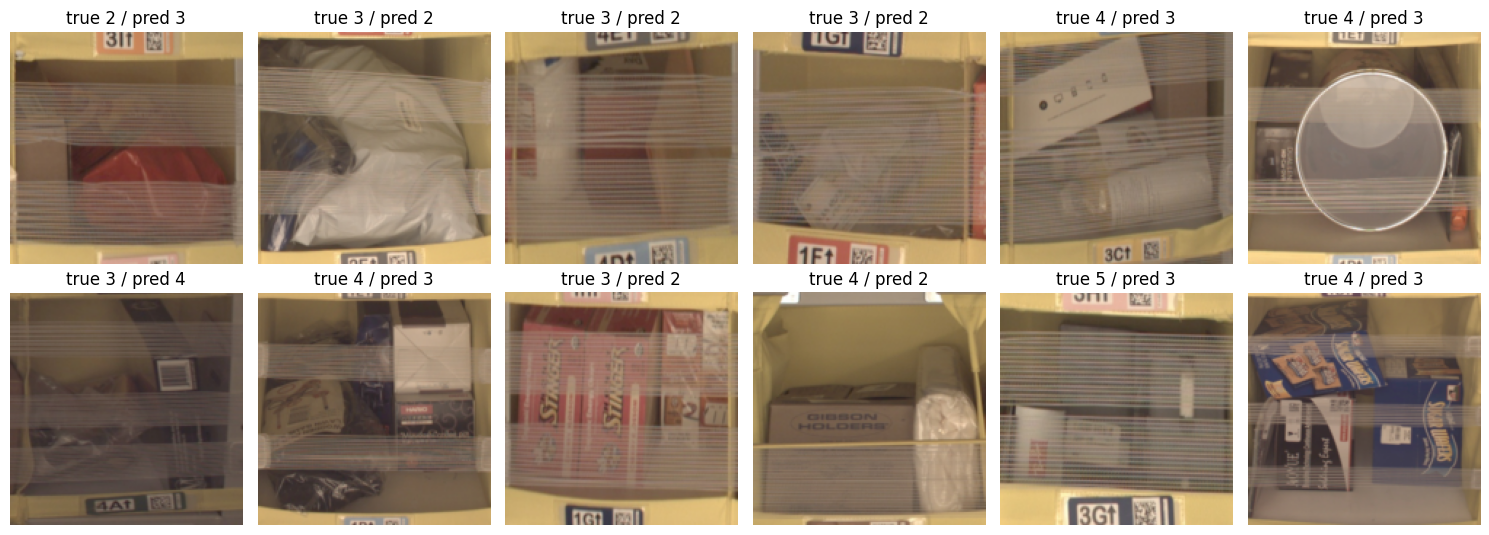

In [14]:
# Error analysis: look at mistakes (what does the model get wrong, and is it even countable?)
wrong = np.where(p != yte)[0]
sel = np.random.RandomState(0).choice(wrong, min(12, len(wrong)), replace=False)
fig, axs = plt.subplots(2, 6, figsize=(15, 5.5))
for a, j in zip(axs.ravel(), sel):
    a.imshow(Xte[j]); a.set_title(f"true {yte[j]} / pred {p[j]}"); a.axis("off")
plt.tight_layout(); plt.show()

## 7. Save the model and export a demo script
The checkpoint stores the weights plus settings. `demo.py` runs on **CPU** (your laptop), so you can demo without a GPU.
Download `model.pt` and `demo.py`, and commit them to your GitHub repo.

In [16]:
torch.save({"arch": "resnet34" if best_name.startswith("C") else "resnet18", "img": IMG, "num_classes": NUM_CLASSES,
            "state_dict": final[best_name].state_dict()}, "model.pt")
print("saved model.pt  (best =", best_name, ")")
print("NOTE: if best model was ResNet34, change arch above to resnet34 before saving.")

saved model.pt  (best = B fine-tuned ResNet18 )
NOTE: if best model was ResNet34, change arch above to resnet34 before saving.


In [17]:
%%writefile demo.py
# Usage: python demo.py path/to/bin_photo.jpg [more.jpg ...]
import sys, torch, torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import models

ck = torch.load("model.pt", map_location="cpu")
model = getattr(models, ck["arch"])(weights=None)
model.fc = nn.Linear(model.fc.in_features, ck["num_classes"])
model.load_state_dict(ck["state_dict"]); model.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def predict(path):
    img = Image.open(path).convert("RGB").resize((ck["img"], ck["img"]), Image.BILINEAR)
    x = torch.from_numpy(np.asarray(img, dtype=np.uint8)).permute(2, 0, 1).float().div(255).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(model((x - mean) / std), 1)[0]
    return int(probs.argmax()), probs

if __name__ == "__main__":
    for path in sys.argv[1:]:
        c, pr = predict(path)
        print(f"{path}: predicted {c} item(s)  (confidence {pr[c]:.0%})")

Writing demo.py


In [18]:
%%writefile requirements.txt
torch
torchvision
numpy
pillow
scikit-learn
pandas
matplotlib
requests
tqdm

Writing requirements.txt


In [19]:
# Save a few test photos to use in the live demo, then download everything.
os.makedirs("sample_images", exist_ok=True)
for c in range(NUM_CLASSES):
    j = np.where(yte == c)[0][0]
    Image.fromarray(Xte[j]).save(f"sample_images/true_{c}_items.jpg")
!zip -qr demo_files.zip model.pt demo.py requirements.txt sample_images
from google.colab import files
files.download("demo_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>